In [1]:
import os
from PIL import Image
import warnings
import pathlib

import cv2
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torch import optim
import torch.functional as F
from torchvision import models

from transformers import ViTForImageClassification, ViTImageProcessor

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')

/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# class STFT_dataset(Dataset):
#     def __init__(self, folder_path: pathlib.Path, processor=None) -> None:
#         self.paths = self.return_img(folder_path)
#         self.processor = processor  

#     def return_img(self, folder_path: pathlib.Path) -> list:
#         paths_list = []
#         for root, _, files in os.walk(folder_path):
#             print(root)
#             for file in files:
#                 if file.endswith((".png", ".jpg", ".jpeg")):  
#                     paths_list.append(os.path.join(root, file))
#         return paths_list

#     def __len__(self) -> int:
#         return len(self.paths)
    
#     def __getitem__(self, idx):
#         path = self.paths[idx]
        
#         img = cv2.imread(path, cv2.IMREAD_COLOR_RGB)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 

#         if self.processor:
#             img = self.processor(img, return_tensors="pt")["pixel_values"].squeeze(0)
#         else:
#             img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)  

#         # --- etykieta ---
#         filename = os.path.basename(path)     
#         label_str = filename.split("_")[-1].split(".")[0]  
#         label = int(label_str)

#         return img, torch.tensor(label, dtype=torch.long)

class STFT_dataset(Dataset):
    def __init__(self, paths: pathlib.Path, processor = None) -> None:
        self.paths = paths
        self.processor = processor

    def __len__(self):
        return  len(self.paths)
    
    def __getitem__(self, idx):
        path = self.paths[idx]
        
        img = cv2.imread(path, cv2.IMREAD_COLOR_RGB)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 

        if self.processor:
            img = self.processor(img, return_tensors="pt")["pixel_values"].squeeze(0)
        else:
            img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)  

        filename = os.path.basename(path)     
        label_str = filename.split("_")[-1].split(".")[0]  
        label = int(label_str)

        return img, torch.tensor(label, dtype=torch.long)
    
def return_img(folder_path: pathlib.Path) -> list:
    paths_list = []
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith((".png", ".jpg", ".jpeg")):  
                paths_list.append(os.path.join(root, file))
    return paths_list

In [3]:
model_name = "google/vit-base-patch16-224-in21k"
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2
)
model.to(device)

processor = ViTImageProcessor.from_pretrained(model_name)

BATCH_SIZE = 8

train_path = pathlib.Path(r"/home/patryk/Desktop/MASTER_THIESIS/spectogram_wieliczka")
eval_path = pathlib.Path(r"/home/patryk/Desktop/MASTER_THIESIS/spectogram_ziemowit")

train_imgs = return_img(train_path)
train_imgs, test_imgs = train_test_split(train_imgs, test_size=0.2, random_state=42)
eval_imgs = return_img(eval_path)

train_dataset = STFT_dataset(train_imgs, processor)
test_dataset = STFT_dataset(test_imgs, processor)
eval_dataset = STFT_dataset(eval_imgs, processor)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
eval_dataloader = DataLoader(eval_dataset, shuffle=False)


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


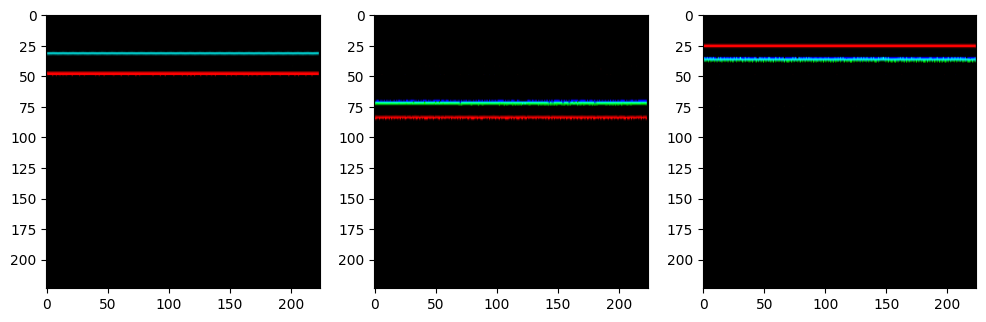

In [4]:
fig, axes = plt.subplots(1, 3, figsize = (12, 4))

axes[0].imshow(np.array(next(iter(train_dataloader))[0][3]).transpose(1, 2, 0))
axes[1].imshow(np.array(next(iter(test_dataloader))[0][3]).transpose(1, 2, 0))
axes[2].imshow(np.array(next(iter(eval_dataloader))[0][0]).transpose(1, 2, 0))

In [5]:
next(iter(eval_dataloader))[0][0].shape

torch.Size([3, 224, 224])

In [6]:
class TorchTrainer:
    def __init__(self, model: nn.Module, device=None):
        self.model = model
        self.device = device if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

        # historia metryk
        self.history = {
            "train_loss": [],
            "train_acc": [],
            "test_loss": [],
            "test_acc": []
        }

    def _accuracy(self, outputs, labels):
        preds = torch.argmax(outputs, dim=1)
        return (preds == labels).float().mean().item()

    def fit(self, train_loader, test_loader, optimizer, criterion, epochs=10):
        for epoch in tqdm(range(epochs)):
            # --- trening ---
            self.model.train()
            train_loss, train_acc = 0.0, 0.0

            for x, y in train_loader:
                x, y = x.to(self.device), y.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(x)
                loss = criterion(outputs, y)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                train_acc += self._accuracy(outputs, y)

            train_loss /= len(train_loader)
            train_acc /= len(train_loader)

            # --- ewaluacja ---
            self.model.eval()
            test_loss, test_acc = 0.0, 0.0
            with torch.no_grad():
                for x, y in test_loader:
                    x, y = x.to(self.device), y.to(self.device)
                    outputs = self.model(x)
                    loss = criterion(outputs, y)
                    test_loss += loss.item()
                    test_acc += self._accuracy(outputs, y)

            test_loss /= len(test_loader)
            test_acc /= len(test_loader)

            # zapisywanie historii
            self.history["train_loss"].append(train_loss)
            self.history["train_acc"].append(train_acc)
            self.history["test_loss"].append(test_loss)
            self.history["test_acc"].append(test_acc)

            print(
                f"Epoch [{epoch+1}/{epochs}] "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
            )

        return self.history

### Train mobile Net with covertet layer 
- ReLU6 -> ReLU
- DepthWise -> Conv2d


In [7]:
# model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights)

# model.classifier = nn.Linear(model.last_channel, 2)
model = torch.load("mobilenet_v2_conv2dBlock.pth", weights_only=False)

trainer = TorchTrainer(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-5)

history = trainer.fit(train_dataloader, test_dataloader, optimizer, criterion, epochs=80)

torch.save(model.state_dict(), "mobilenet_v2_conv2dBlock_fineTune.pth")

  1%|█▋                                                                                                                                  | 1/80 [00:05<06:36,  5.02s/it]

Epoch [1/80] Train Loss: 0.5899, Train Acc: 0.7143 | Test Loss: 0.6209, Test Acc: 0.6875


  2%|███▎                                                                                                                                | 2/80 [00:07<04:46,  3.67s/it]

Epoch [2/80] Train Loss: 0.4958, Train Acc: 0.7798 | Test Loss: 0.6907, Test Acc: 0.6875


  4%|████▉                                                                                                                               | 3/80 [00:10<04:06,  3.20s/it]

...

Epoch [78/80] Train Loss: 0.0616, Train Acc: 0.9762 | Test Loss: 0.0330, Test Acc: 0.9792


 99%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎ | 79/80 [03:47<00:02,  2.95s/it]

Epoch [79/80] Train Loss: 0.0509, Train Acc: 0.9881 | Test Loss: 0.0177, Test Acc: 1.0000


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [03:50<00:00,  2.88s/it]

Epoch [80/80] Train Loss: 0.0152, Train Acc: 1.0000 | Test Loss: 0.0158, Test Acc: 1.0000


In [8]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12,5))

    # --- Loss ---
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over epochs")
    plt.legend()
    plt.grid(True)

    # --- Accuracy ---
    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["test_acc"], label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over epochs")
    plt.legend()
    plt.grid(True)

    plt.show()


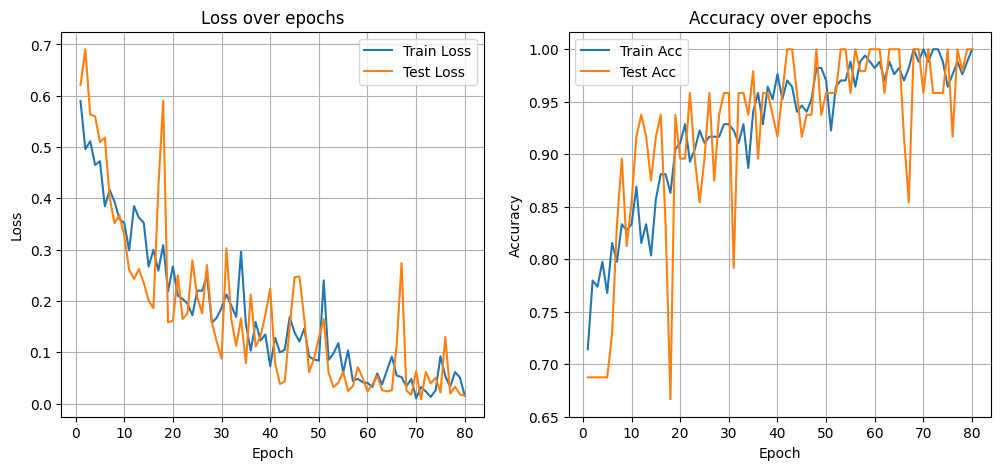

In [9]:
plot_history(history)

In [10]:
model = torch.load("mobilenet_v2_conv2dBlock.pth", weights_only=False)
state_dict = torch.load("mobilenet_v2_conv2dBlock_fineTune.pth")
model.load_state_dict(state_dict)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Liczba wszystkich parametrów: {total_params:,}")
print(f"Liczba trenowalnych parametrów: {trainable_params:,}")

param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
size_all_mb = (param_size + buffer_size) / (1024 ** 2)

print(f"Szacowany rozmiar modelu w pamięci: {size_all_mb:.2f} MB")

path = "mobilenet_v2_conv2dBlock.pth"
file_size_mb = os.path.getsize(path) / (1024 * 1024)
print(f"Rozmiar pliku modelu: {file_size_mb:.2f} MB")

Liczba wszystkich parametrów: 42,772,514
Liczba trenowalnych parametrów: 42,772,514
Szacowany rozmiar modelu w pamięci: 163.29 MB
Rozmiar pliku modelu: 163.43 MB


### Train ResNet30

In [11]:
model = models.resnet34(weights=models.ResNet34_Weights)

trainer = TorchTrainer(model, device)
optimizer = optim.AdamW(params=model.parameters())

history = trainer.fit(train_dataloader, test_dataloader, optimizer=optimizer, criterion=criterion, epochs=20)

torch.save(model, "ResNet34_fineTune.pth")

  5%|██████▌                                                                                                                             | 1/20 [00:01<00:34,  1.80s/it]

Epoch [1/20] Train Loss: 1.5842, Train Acc: 0.7024 | Test Loss: 4.1288, Test Acc: 0.6458


 10%|█████████████▏                                                                                                                      | 2/20 [00:03<00:32,  1.78s/it]

Epoch [2/20] Train Loss: 0.2273, Train Acc: 0.9286 | Test Loss: 0.2088, Test Acc: 0.9583


 15%|███████████████████▊                                                                                                                | 3/20 [00:05<00:30,  1.80s/it]

...

Epoch [18/20] Train Loss: 0.1491, Train Acc: 0.9524 | Test Loss: 0.0235, Test Acc: 1.0000


 95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍      | 19/20 [00:34<00:01,  1.81s/it]

Epoch [19/20] Train Loss: 0.0190, Train Acc: 0.9940 | Test Loss: 0.0040, Test Acc: 1.0000


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:36<00:00,  1.83s/it]

Epoch [20/20] Train Loss: 0.0089, Train Acc: 1.0000 | Test Loss: 0.0033, Test Acc: 1.0000


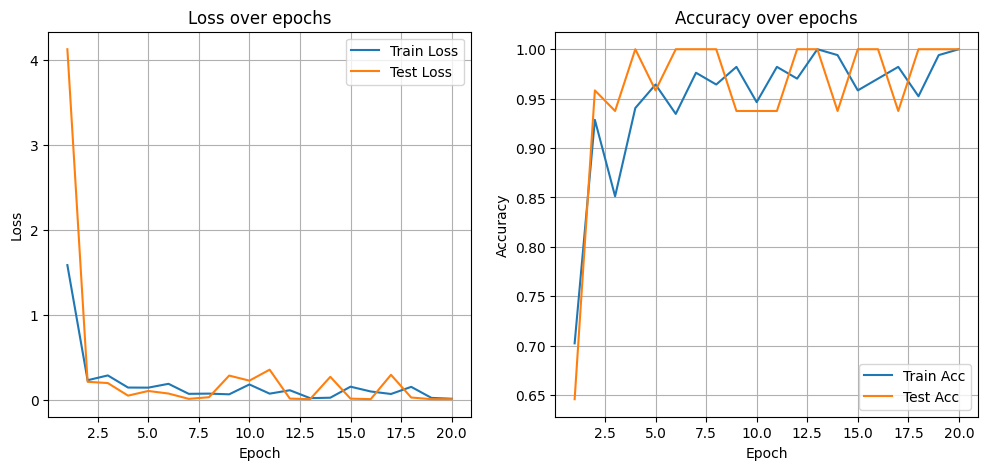

In [12]:
plot_history(history)

In [13]:
model = torch.load("ResNet34_fineTune.pth", weights_only=False)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Liczba wszystkich parametrów: {total_params:,}")
print(f"Liczba trenowalnych parametrów: {trainable_params:,}")

param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
size_all_mb = (param_size + buffer_size) / (1024 ** 2)

print(f"Szacowany rozmiar modelu w pamięci: {size_all_mb:.2f} MB")

path = "ResNet34_fineTune.pth"
file_size_mb = os.path.getsize(path) / (1024 * 1024)
print(f"Rozmiar pliku modelu: {file_size_mb:.2f} MB")

Liczba wszystkich parametrów: 21,797,672
Liczba trenowalnych parametrów: 21,797,672
Szacowany rozmiar modelu w pamięci: 83.22 MB
Rozmiar pliku modelu: 83.31 MB


### Train ResNet18

In [24]:
model = models.resnet18(models.ResNet18_Weights)

trainer = TorchTrainer(model, device)
optimizer = optim.AdamW(params=model.parameters())

history = trainer.fit(train_dataloader, test_dataloader, optimizer=optimizer, criterion=criterion, epochs=10)

torch.save(model, "ResNet18_fineTune.pth")

 10%|█████████████▏                                                                                                                      | 1/10 [00:01<00:11,  1.23s/it]

Epoch [1/10] Train Loss: 1.7627, Train Acc: 0.6845 | Test Loss: 2.6417, Test Acc: 0.5000


 20%|██████████████████████████▍                                                                                                         | 2/10 [00:02<00:09,  1.20s/it]

Epoch [2/10] Train Loss: 0.2066, Train Acc: 0.9286 | Test Loss: 0.4554, Test Acc: 0.9375


 30%|███████████████████████████████████████▌                                                                                            | 3/10 [00:03<00:08,  1.19s/it]

...

Epoch [8/10] Train Loss: 0.0444, Train Acc: 0.9940 | Test Loss: 0.0089, Test Acc: 1.0000


 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊             | 9/10 [00:10<00:01,  1.16s/it]

Epoch [9/10] Train Loss: 0.0343, Train Acc: 0.9821 | Test Loss: 0.0020, Test Acc: 1.0000


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:11<00:00,  1.18s/it]

Epoch [10/10] Train Loss: 0.0481, Train Acc: 0.9762 | Test Loss: 0.0654, Test Acc: 0.9792


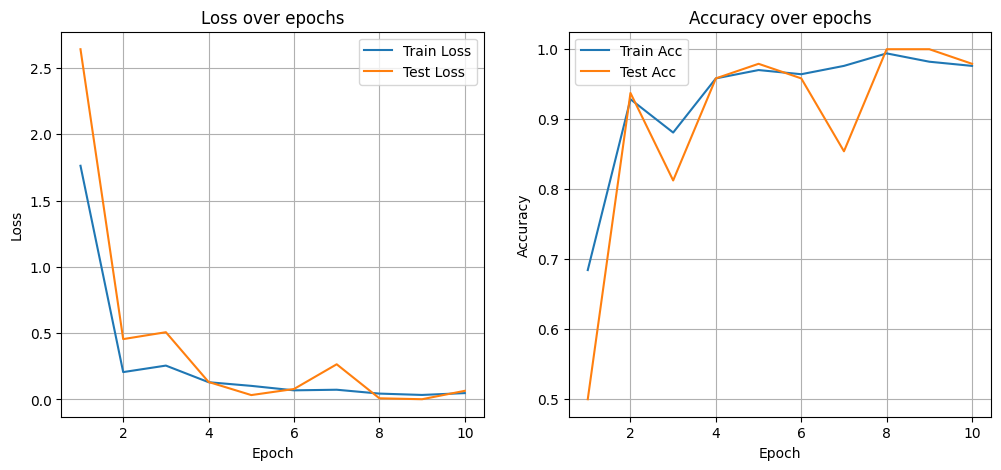

In [25]:
plot_history(history)

In [26]:
model = torch.load("ResNet18_fineTune.pth", weights_only=False)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Liczba wszystkich parametrów: {total_params:,}")
print(f"Liczba trenowalnych parametrów: {trainable_params:,}")

param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
size_all_mb = (param_size + buffer_size) / (1024 ** 2)

print(f"Szacowany rozmiar modelu w pamięci: {size_all_mb:.2f} MB")

path = "ResNet18_fineTune.pth"
file_size_mb = os.path.getsize(path) / (1024 * 1024)
print(f"Rozmiar pliku modelu: {file_size_mb:.2f} MB")

Liczba wszystkich parametrów: 11,689,512
Liczba trenowalnych parametrów: 11,689,512
Szacowany rozmiar modelu w pamięci: 44.63 MB
Rozmiar pliku modelu: 44.68 MB
